# 台灣基準利率模型 — Step 1：特徵工程 (Feature Engineering)

這份 notebook **只做特徵工程**：把 Excel 各分頁清乾淨、對齊成「年季」、合併成一張建模表、
建交互作用項、存 CSV。一格一格跑，每一步都會印出結果檢查。

**變數**

| 代號 | 意義 | 來源分頁 | 單位處理 |
|---|---|---|---|
| Y | 台灣基準利率 | `基準利率` | 不定頻 → 每季取季底生效值 → ffill |
| X1 | 實質 GDP YoY% | `實質GDP YoY%` | 已是百分點 |
| X2 | 季核心 CPI YoY% | `Core CPI YoY%`（自行月轉季） | 已是百分點 |
| X3 | 進口物價指數 YoY% | `Import Index`（自行月轉季） | 小數 → ×100 |
| X4 | 季 M2 YoY% | `Q - TW Money Supply M2 YoY% ` | 已是百分點 |
| X5 | 季房貸餘額 YoY% | `Formosa Housing Loan - Q ` | 小數 → ×100 |
| **X6** | **季零售銷售額 YoY%（新增）** | **`Q - Retail Sales`** | **已是百分點** |

**交互作用項**：不再寫死 4 個。改成先算 X1–X6 的 Pearson 相關矩陣，
**只對「相關係數低」的配對建交互項**（門檻 `INTERACTION_CORR_MAX`，可調）——
低相關的兩個變數相乘，比較不會跟原變數高度共線（避免 $X_i \times X_j \approx X_i^2$ 的冗餘）。

## 0. 環境設定 & 讀取工作簿

In [1]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

XLSX = Path("Data/台灣利率貢獻度分析模型.xlsx")
assert XLSX.exists(), f"找不到檔案：{XLSX.resolve()}"

xls = pd.ExcelFile(XLSX)
xls.sheet_names

['基準利率',
 '實質GDP YoY%',
 'Core CPI YoY%',
 'Quarterly Core CPI YoY%',
 'Retail Sales',
 'Q - Retail Sales',
 'Taiwan Money Supply M2 YoY%',
 'Q - TW Money Supply M2 YoY% ',
 'Formosa Housing Loan',
 'Formosa Housing Loan - Q ',
 'Import Index',
 'PMI',
 'Q-PMI',
 '實質利率 - Not Finish']

### 分頁名對照表

有幾個分頁名稱**結尾有空白**（`'Q - TW Money Supply M2 YoY% '`、`'Formosa Housing Loan - Q '`），
直接用去空白的名字 `read_excel` 會失敗。先做一個 `strip 後 -> 原始名` 的對照表。

In [2]:
SHEETS = {s.strip(): s for s in xls.sheet_names}
SHEETS

{'基準利率': '基準利率',
 '實質GDP YoY%': '實質GDP YoY%',
 'Core CPI YoY%': 'Core CPI YoY%',
 'Quarterly Core CPI YoY%': 'Quarterly Core CPI YoY%',
 'Retail Sales': 'Retail Sales',
 'Q - Retail Sales': 'Q - Retail Sales',
 'Taiwan Money Supply M2 YoY%': 'Taiwan Money Supply M2 YoY%',
 'Q - TW Money Supply M2 YoY%': 'Q - TW Money Supply M2 YoY% ',
 'Formosa Housing Loan': 'Formosa Housing Loan',
 'Formosa Housing Loan - Q': 'Formosa Housing Loan - Q ',
 'Import Index': 'Import Index',
 'PMI': 'PMI',
 'Q-PMI': 'Q-PMI',
 '實質利率 - Not Finish': '實質利率 - Not Finish'}

### 小工具：讀一個分頁並清欄名

欄名也可能有頭尾空白（`'Import Price Index '`），一律 `.strip()`。

In [3]:
def read_sheet(name: str) -> pd.DataFrame:
    df = pd.read_excel(XLSX, sheet_name=SHEETS.get(name.strip(), name))
    df.columns = [str(c).strip() for c in df.columns]
    return df

## 1. Y = 台灣基準利率：不定頻 → 季

`基準利率` 分頁是「央行理監事會決議日 / 早期逐日」的資料，不是固定頻率。
1. 丟掉利率為空的列（例如 `2026-08-31` 那種佔位列）
2. 依日期排序
3. **每一季取「該季最後一個已知利率」**（季底生效值）
4. 沒開會、利率沒變的季 → `ffill` 沿用前一季

In [4]:
raw_y = read_sheet("基準利率")
print(raw_y.shape, "| 欄位：", list(raw_y.columns))
raw_y.head()

(204, 2) | 欄位： ['Date', '台灣基準利率']


,Date,台灣基準利率
0,2026-08-31,NaN
1,2026-06-18,2.0
2,2026-03-19,2.0
3,2025-12-18,2.0
4,2025-09-18,2.0


In [5]:
y = raw_y[["Date", "台灣基準利率"]].copy()
y["Date"] = pd.to_datetime(y["Date"], errors="coerce")

before = len(y)
y = y.dropna(subset=["Date", "台灣基準利率"]).sort_values("Date")
print(f"丟掉空值列：{before} -> {len(y)}")
print("日期範圍：", y["Date"].min().date(), "~", y["Date"].max().date())
y.tail()

丟掉空值列：204 -> 203
日期範圍： 2000-09-01 ~ 2026-06-18


,Date,台灣基準利率
5,2025-06-19,2.0
4,2025-09-18,2.0
3,2025-12-18,2.0
2,2026-03-19,2.0
1,2026-06-18,2.0


In [6]:
# 每季取季底最後一筆生效利率
s = y.set_index("Date")["台灣基準利率"]
Y_q = s.groupby(s.index.to_period("Q")).last()

full_q = pd.period_range(Y_q.index.min(), Y_q.index.max(), freq="Q")
Y_q = Y_q.reindex(full_q).ffill()
Y_q.name = "Y_基準利率"

print(f"季序列：{len(Y_q)} 季，{Y_q.index[0]} ~ {Y_q.index[-1]}")
Y_q.tail(8)

季序列：104 季，2000Q3 ~ 2026Q2


2024Q3    2.0
2024Q4    2.0
2025Q1    2.0
2025Q2    2.0
2025Q3    2.0
2025Q4    2.0
2026Q1    2.0
2026Q2    2.0
Freq: Q-DEC, Name: Y_基準利率, dtype: float64

## 2. X1 = 實質 GDP YoY%

`實質GDP YoY%` 分頁，欄位 `GDP by Chain Value YoY%`。標準季底日期（3/31…12/31），
單位已是百分點（`12.929` = 12.929%），直接 `to_period('Q')` 對齊。

In [7]:
raw_x1 = read_sheet("實質GDP YoY%")
print(raw_x1.shape, list(raw_x1.columns))
raw_x1.head()

(104, 2) ['Date', 'GDP by Chain Value YoY%']


,Date,GDP by Chain Value YoY%
0,2026-06-30,12.929
1,2026-03-31,15.426
2,2025-12-31,12.952
3,2025-09-30,8.417
4,2025-06-30,7.705


In [8]:
x1 = raw_x1[["Date", "GDP by Chain Value YoY%"]].copy()
x1["Date"] = pd.to_datetime(x1["Date"])
X1 = x1.set_index(x1["Date"].dt.to_period("Q"))["GDP by Chain Value YoY%"].sort_index()
X1.name = "X1"
print(f"{len(X1)} 季，{X1.index[0]} ~ {X1.index[-1]}")
X1.tail()

104 季，2000Q3 ~ 2026Q2


Date
2025Q2     7.705
2025Q3     8.417
2025Q4    12.952
2026Q1    15.426
2026Q2    12.929
Freq: Q-DEC, Name: X1, dtype: float64

## 3. X2 = 季核心 CPI YoY%（自行從月頻重建）

原本指定的 `Quarterly Core CPI YoY%` 分頁 172 列裡只有 70 列有有效日期（其餘 `NaT`）、
月份戳不一致，沒法可靠對齊。改用**月頻** `Core CPI YoY%` 欄，自己以「日曆季平均」重建，
一季至少 2 個月才算。

In [9]:
raw_x2 = read_sheet("Core CPI YoY%")
print(raw_x2.shape, list(raw_x2.columns))
raw_x2.head()

(312, 4) ['Date', 'Core CPI YoY%', 'Quarter Core CPI YoY%', 'Quarter Core CPI YoY%.1']


,Date,Core CPI YoY%,Quarter Core CPI YoY%,Quarter Core CPI YoY%.1
0,2026-07-31,2.38,2.313333,2.313333
1,2026-06-30,2.44,NaN,NaN
2,2026-05-31,2.12,NaN,NaN
3,2026-04-30,1.90,2.150000,2.150000
4,2026-03-31,1.94,NaN,NaN


In [10]:
x2 = raw_x2[["Date", "Core CPI YoY%"]].copy()
x2["Date"] = pd.to_datetime(x2["Date"], errors="coerce")
x2["Core CPI YoY%"] = pd.to_numeric(x2["Core CPI YoY%"], errors="coerce")
x2 = x2.dropna(subset=["Date"])
x2["Q"] = x2["Date"].dt.to_period("Q")

g = x2.groupby("Q")["Core CPI YoY%"]
X2 = g.mean().where(g.count() >= 2).dropna()
X2.name = "X2"
print(f"{len(X2)} 季，{X2.index[0]} ~ {X2.index[-1]}")
X2.tail()

104 季，2000Q3 ~ 2026Q2


Q
2025Q2    1.580000
2025Q3    1.633333
2025Q4    1.790000
2026Q1    1.933333
2026Q2    2.153333
Freq: Q-DEC, Name: X2, dtype: float64

In [11]:
# 對照：每季用了幾個月、平均值多少
pd.DataFrame({"月數": g.count(), "季平均": g.mean().round(3)}).tail(6)

,月數,季平均
Q,,
2025Q2,3,1.580
2025Q3,3,1.633
2025Q4,3,1.790
2026Q1,3,1.933
2026Q2,3,2.153
2026Q3,1,2.380


## 4. X3 = 進口物價指數 YoY%（月頻 → 季，單位換算）

`Import Index` 分頁只有月頻 `Import Price Index YoY%`，自己季平均。
單位是**小數比例**（`0.01688` = 1.688%），**×100** 換成百分點。

In [12]:
raw_x3 = read_sheet("Import Index")
print(raw_x3.shape, list(raw_x3.columns))
raw_x3.head()

(315, 3) ['Date', 'Import Price Index', 'Import Price Index YoY%']


,Date,Import Price Index,Import Price Index YoY%
0,2026-07-31,-0.399,-0.00399
1,2026-06-30,-0.266,-0.00266
2,2026-05-31,1.688,0.01688
3,2026-04-30,2.279,0.02279
4,2026-03-31,0.906,0.00906


In [13]:
x3 = raw_x3[["Date", "Import Price Index YoY%"]].copy()
x3["Date"] = pd.to_datetime(x3["Date"], errors="coerce")
x3["Import Price Index YoY%"] = pd.to_numeric(x3["Import Price Index YoY%"], errors="coerce")
x3 = x3.dropna(subset=["Date"])
x3["Q"] = x3["Date"].dt.to_period("Q")

g3 = x3.groupby("Q")["Import Price Index YoY%"]
X3 = (g3.mean() * 100).where(g3.count() >= 2).dropna()
X3.name = "X3"
print(f"{len(X3)} 季，{X3.index[0]} ~ {X3.index[-1]}")
X3.tail()

105 季，2000Q2 ~ 2026Q2


Q
2025Q2   -0.188333
2025Q3    0.000000
2025Q4   -3.666000
2026Q1    0.795333
2026Q2    1.233667
Freq: Q-DEC, Name: X3, dtype: float64

## 5. X4 = 季 M2 YoY%（用內建季分頁）

`Q - TW Money Supply M2 YoY% `（結尾有空白），欄位 `Quarterly Taiwan Money Supply M2 YoY%`。
月份戳 2/5/8/11 → `to_period('Q')` 落到 Q1–Q4。單位已是百分點。

In [14]:
raw_x4 = read_sheet("Q - TW Money Supply M2 YoY%")
print(raw_x4.shape, list(raw_x4.columns))
raw_x4.head()

(104, 2) ['Date', 'Quarterly Taiwan Money Supply M2 YoY%']


,Date,Quarterly Taiwan Money Supply M2 YoY%
0,2026-05-31,7.143333
1,2026-02-28,5.426667
2,2025-11-30,5.240000
3,2025-08-31,4.066667
4,2025-05-31,3.606667


In [15]:
x4 = raw_x4[["Date", "Quarterly Taiwan Money Supply M2 YoY%"]].copy()
x4["Date"] = pd.to_datetime(x4["Date"])
x4["Quarterly Taiwan Money Supply M2 YoY%"] = pd.to_numeric(
    x4["Quarterly Taiwan Money Supply M2 YoY%"], errors="coerce")
x4 = x4.dropna()
X4 = x4.set_index(x4["Date"].dt.to_period("Q"))["Quarterly Taiwan Money Supply M2 YoY%"].sort_index()
X4.name = "X4"
print(f"{len(X4)} 季，{X4.index[0]} ~ {X4.index[-1]}")
X4.tail()

104 季，2000Q3 ~ 2026Q2


Date
2025Q2    3.606667
2025Q3    4.066667
2025Q4    5.240000
2026Q1    5.426667
2026Q2    7.143333
Freq: Q-DEC, Name: X4, dtype: float64

## 6. X5 = 季房貸餘額 YoY%（用內建季分頁，單位換算）

`Formosa Housing Loan - Q `（結尾有空白），欄位 `Quarterly Taiwan Consumer Housing Loan YoY%`。
月份戳 2/5/8/11 → `to_period('Q')`。單位是**小數比例**（`0.044` = 4.4%）→ **×100**。
這個分頁最早只到 **2001Q3**，是整份建模表的起點。

In [16]:
raw_x5 = read_sheet("Formosa Housing Loan - Q")
print(raw_x5.shape, list(raw_x5.columns))
raw_x5.head()

(100, 2) ['Date', 'Quarterly Taiwan Consumer Housing Loan YoY%']


,Date,Quarterly Taiwan Consumer Housing Loan YoY%
0,2026-05-31,0.044364
1,2026-02-28,0.045019
2,2025-11-30,0.051099
3,2025-08-31,0.068013
4,2025-05-31,0.087195


In [17]:
x5 = raw_x5[["Date", "Quarterly Taiwan Consumer Housing Loan YoY%"]].copy()
x5["Date"] = pd.to_datetime(x5["Date"])
x5["Quarterly Taiwan Consumer Housing Loan YoY%"] = pd.to_numeric(
    x5["Quarterly Taiwan Consumer Housing Loan YoY%"], errors="coerce")
x5 = x5.dropna()
X5 = (x5.set_index(x5["Date"].dt.to_period("Q"))["Quarterly Taiwan Consumer Housing Loan YoY%"]
      .sort_index() * 100)
X5.name = "X5"
print(f"{len(X5)} 季，{X5.index[0]} ~ {X5.index[-1]}")
X5.tail()

100 季，2001Q3 ~ 2026Q2


Date
2025Q2    8.719529
2025Q3    6.801323
2025Q4    5.109925
2026Q1    4.501858
2026Q2    4.436409
Freq: Q-DEC, Name: X5, dtype: float64

## 7. X6 = 季零售銷售額 YoY%（新增，用內建季分頁）

新資料 `Q - Retail Sales` 分頁，欄位 `Retail - Q`。
- 月份戳在 1/4/7/10 月（= 該季最後一個月的「近三個月平均」），`to_period('Q')` 落到 Q1–Q4。
- 數值是 **YoY% 百分點**（`6.98` = 零售額年增 6.98%），和 X1/X2/X4 同尺度，**不用 ×100**。
- 涵蓋期間 2000Q3 ~ 2026Q3，比 X5（2001Q3 起）長，所以不會改變建模表的起點。

In [18]:
raw_x6 = read_sheet("Q - Retail Sales")
print(raw_x6.shape, list(raw_x6.columns))
raw_x6.head()

(105, 2) ['Date', 'Retail - Q']


,Date,Retail - Q
0,2026-07-31,6.983333
1,2026-04-30,5.406667
2,2026-01-31,-0.323333
3,2025-10-31,0.213333
4,2025-07-31,-2.610000


In [19]:
x6 = raw_x6[["Date", "Retail - Q"]].copy()
x6["Date"] = pd.to_datetime(x6["Date"])
x6["Retail - Q"] = pd.to_numeric(x6["Retail - Q"], errors="coerce")
x6 = x6.dropna()
X6 = x6.set_index(x6["Date"].dt.to_period("Q"))["Retail - Q"].sort_index()
X6.name = "X6"
print(f"{len(X6)} 季，{X6.index[0]} ~ {X6.index[-1]}")
X6.tail()

105 季，2000Q3 ~ 2026Q3


Date
2025Q3   -2.610000
2025Q4    0.213333
2026Q1   -0.323333
2026Q2    5.406667
2026Q3    6.983333
Freq: Q-DEC, Name: X6, dtype: float64

## 8. 合併成一張建模表

用「年季」PeriodIndex 對齊（不是用日期字串 join）。`dropna()` 後留下 7 個序列都有值的季，
理論上是 **2001Q3 ~ 2026Q2**（起點卡在 X5，終點卡在 X1 / X4 / X5）。

> **另一個新資料 PMI**：`Q-PMI` 分頁（欄位 `TW PMI - Q`，PMI 擴散指數水準，非 YoY%）也在檔案裡了，
> 但它**只從 2012Q4 開始**，若納入會把樣本從 ~100 季砍到 ~55 季，所以這裡先不放。
> 要加的話，比照 X6 讀 `Q-PMI` → `to_period('Q')`，在這一格的 `concat` 補上 `"X7": X7` 即可。

In [20]:
data = pd.concat(
    {"Y_基準利率": Y_q, "X1": X1, "X2": X2, "X3": X3, "X4": X4, "X5": X5, "X6": X6},
    axis=1,
)
print("對齊後（未 dropna）：", data.shape)
print("各欄缺值數：")
print(data.isna().sum())
data

對齊後（未 dropna）： (106, 7)
各欄缺值數：
Y_基準利率    2
X1        2
X2        2
X3        1
X4        2
X5        6
X6        1
dtype: int64


,Y_基準利率,X1,X2,X3,X4,X5,X6
2000Q3,4.750,7.189,0.655000,0.465000,6.480000,NaN,6.323333
2000Q4,4.625,5.783,0.773333,-0.362000,6.440000,NaN,6.643333
2001Q1,4.125,1.453,0.616667,-0.733000,6.206667,NaN,2.680000
2001Q2,3.500,-2.552,0.086667,-0.237333,5.263333,NaN,-2.146667
2001Q3,2.750,-4.064,-0.323333,-0.581667,6.476667,3.070583,-3.690000
...,...,...,...,...,...,...,...
2025Q4,2.000,12.952,1.790000,-3.666000,5.240000,5.109925,0.213333
2026Q1,2.000,15.426,1.933333,0.795333,5.426667,4.501858,-0.323333
2026Q2,2.000,12.929,2.153333,1.233667,7.143333,4.436409,5.406667
2000Q2,NaN,NaN,NaN,0.861000,NaN,NaN,NaN


In [21]:
data = data.dropna().copy()
print("dropna 後：", data.shape, "|", data.index[0], "~", data.index[-1])
data.head()

dropna 後： (100, 7) | 2001Q3 ~ 2026Q2


,Y_基準利率,X1,X2,X3,X4,X5,X6
2001Q3,2.750,-4.064,-0.323333,-0.581667,6.476667,3.070583,-3.690000
2001Q4,2.125,-0.302,-0.603333,-1.587667,5.600000,0.629032,-3.400000
2002Q1,2.125,1.823,0.466667,0.509667,4.030000,-0.787850,1.946667
2002Q2,1.875,6.751,0.656667,0.468000,4.286667,-0.126594,3.796667
2002Q3,1.875,7.025,0.770000,0.493333,2.956667,1.582225,5.733333


## 9. X1–X6 相關矩陣

在建交互項之前，先看六個解釋變數彼此的 **Pearson 相關係數**。
下一節只會挑「相關低」的配對來相乘。

,X1,X2,X3,X4,X5,X6
X1,1.000,0.004,0.318,-0.001,0.383,0.422
X2,0.004,1.000,-0.080,-0.015,0.088,0.190
X3,0.318,-0.080,1.000,0.104,0.213,0.259
X4,-0.001,-0.015,0.104,1.000,0.386,0.164
X5,0.383,0.088,0.213,0.386,1.000,0.400
X6,0.422,0.190,0.259,0.164,0.400,1.000


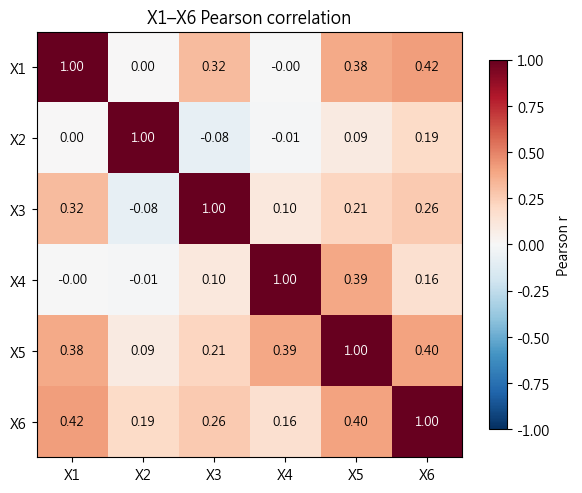

In [22]:
BASE_VARS = ["X1", "X2", "X3", "X4", "X5", "X6"]
corr = data[BASE_VARS].corr()          # Pearson
display(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(BASE_VARS))); ax.set_xticklabels(BASE_VARS)
ax.set_yticks(range(len(BASE_VARS))); ax.set_yticklabels(BASE_VARS)
for i in range(len(BASE_VARS)):
    for j in range(len(BASE_VARS)):
        r = corr.iloc[i, j]
        ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(r) > 0.55 else "black")
fig.colorbar(im, ax=ax, shrink=.85, label="Pearson r")
ax.set_title("X1–X6 Pearson correlation")
plt.tight_layout(); plt.show()

## 10. 交互作用項：只挑「低相關」的配對

6 個變數共 $\binom{6}{2}=15$ 個配對。把 15 個配對按 $|r|$ 由小到大排，
**只對 $|r| \le$ `INTERACTION_CORR_MAX` 的配對建交互項** $X_a \times X_b$。

想法：兩個變數相關越低，它們的乘積帶來的資訊越「新」，也越不會跟原變數共線
（高相關的兩個變數相乘會逼近 $X_i^2$，VIF 會爆）。門檻可自行調整。

In [23]:
INTERACTION_CORR_MAX = 0.35     # 只對 |Pearson r| <= 此門檻的配對建交互項（可調）

pair_r = [(a, b, float(corr.loc[a, b])) for a, b in itertools.combinations(BASE_VARS, 2)]
pair_r.sort(key=lambda t: abs(t[2]))            # 相關最低的排前面

pair_tbl = pd.DataFrame(pair_r, columns=["var_a", "var_b", "pearson_r"])
pair_tbl["abs_r"] = pair_tbl["pearson_r"].abs()
pair_tbl["選為交互項"] = pair_tbl["abs_r"] <= INTERACTION_CORR_MAX
print(f"15 個配對中，|r| <= {INTERACTION_CORR_MAX} 的有 {int(pair_tbl['選為交互項'].sum())} 個")
pair_tbl.round(3)

15 個配對中，|r| <= 0.35 的有 11 個


,var_a,var_b,pearson_r,abs_r,選為交互項
0,X1,X4,-0.001,0.001,True
1,X1,X2,0.004,0.004,True
2,X2,X4,-0.015,0.015,True
3,X2,X3,-0.080,0.080,True
4,X2,X5,0.088,0.088,True
5,X3,X4,0.104,0.104,True
6,X4,X6,0.164,0.164,True
7,X2,X6,0.190,0.190,True
8,X3,X5,0.213,0.213,True
9,X3,X6,0.259,0.259,True


In [24]:
chosen_pairs = [(a, b) for a, b, r in pair_r if abs(r) <= INTERACTION_CORR_MAX]

for a, b in chosen_pairs:
    data[f"{a}_{b}"] = data[a] * data[b]

INT_COLS = [f"{a}_{b}" for a, b in chosen_pairs]
data = data[["Y_基準利率"] + BASE_VARS + INT_COLS].copy()
print(f"新增 {len(INT_COLS)} 個交互項：{INT_COLS}")
data.head()

新增 11 個交互項：['X1_X4', 'X1_X2', 'X2_X4', 'X2_X3', 'X2_X5', 'X3_X4', 'X4_X6', 'X2_X6', 'X3_X5', 'X3_X6', 'X1_X3']


,Y_基準利率,X1,X2,X3,X4,X5,X6,X1_X4,X1_X2,X2_X4,X2_X3,X2_X5,X3_X4,X4_X6,X2_X6,X3_X5,X3_X6,X1_X3
2001Q3,2.750,-4.064,-0.323333,-0.581667,6.476667,3.070583,-3.690000,-26.321173,1.314027,-2.094122,0.188072,-0.992822,-3.767261,-23.898900,1.193100,-1.786056,2.146350,2.363893
2001Q4,2.125,-0.302,-0.603333,-1.587667,5.600000,0.629032,-3.400000,-1.691200,0.182207,-3.378667,0.957892,-0.379516,-8.890933,-19.040000,2.051333,-0.998693,5.398067,0.479475
2002Q1,2.125,1.823,0.466667,0.509667,4.030000,-0.787850,1.946667,7.346690,0.850733,1.880667,0.237844,-0.367663,2.053957,7.845067,0.908444,-0.401541,0.992151,0.929122
2002Q2,1.875,6.751,0.656667,0.468000,4.286667,-0.126594,3.796667,28.939287,4.433157,2.814911,0.307320,-0.083130,2.006160,16.275044,2.493144,-0.059246,1.776840,3.159468
2002Q3,1.875,7.025,0.770000,0.493333,2.956667,1.582225,5.733333,20.770583,5.409250,2.276633,0.379867,1.218314,1.458622,16.951556,4.414667,0.780565,2.828444,3.465667


### 檢查：低相關配對的交互項，是不是真的比較不共線？

看每個新交互項跟它兩個「母變數」的相關；母變數相關越低，交互項越不會被某個母變數主導。

In [25]:
rows = []
for a, b in chosen_pairs:
    col = f"{a}_{b}"
    rows.append({
        "交互項": col,
        "母變數 |r|": abs(corr.loc[a, b]),
        f"|corr| vs {a}": abs(data[col].corr(data[a])),
        f"|corr| vs {b}": abs(data[col].corr(data[b])),
    })
pd.DataFrame(rows).round(3)

,交互項,母變數 |r|,|corr| vs X1,|corr| vs X4,|corr| vs X2,|corr| vs X3,|corr| vs X5,|corr| vs X6
0,X1_X4,0.001,0.919,0.297,NaN,NaN,NaN,NaN
1,X1_X2,0.004,0.703,NaN,0.387,NaN,NaN,NaN
2,X2_X4,0.015,NaN,0.392,0.841,NaN,NaN,NaN
3,X2_X3,0.080,NaN,NaN,0.048,0.858,NaN,NaN
4,X2_X5,0.088,NaN,NaN,0.809,NaN,0.545,NaN
5,X3_X4,0.104,NaN,0.236,NaN,0.949,NaN,NaN
6,X4_X6,0.164,NaN,0.310,NaN,NaN,NaN,0.955
7,X2_X6,0.190,NaN,NaN,0.441,NaN,NaN,0.780
8,X3_X5,0.213,NaN,NaN,NaN,0.850,0.381,NaN
9,X3_X6,0.259,NaN,NaN,NaN,0.055,NaN,0.132


## 11. 敘述統計

In [26]:
data.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
Y_基準利率,100.0,1.802,0.557,1.125,1.375,1.875,2.000,3.625
X1,100.0,4.199,3.953,-7.872,2.153,4.197,6.399,15.426
X2,100.0,1.086,0.919,-0.837,0.571,0.913,1.587,3.937
X3,100.0,0.114,1.108,-5.980,-0.291,0.239,0.529,2.910
X4,100.0,5.288,1.670,1.423,3.950,5.435,6.467,8.970
X5,100.0,6.164,3.472,-0.788,4.180,5.064,8.016,15.492
X6,100.0,2.853,4.313,-7.007,0.429,2.840,5.407,16.223
X1_X4,100.0,22.199,24.567,-53.792,9.786,21.548,33.534,92.356
X1_X2,100.0,4.576,6.973,-19.989,1.154,3.534,6.921,29.824
X2_X4,100.0,5.722,5.410,-7.048,2.697,4.389,7.998,21.049


## 12. 存成 CSV

之後建模直接 `pd.read_csv(...)`。欄位順序：`年季, Y_基準利率, X1..X6, <低相關交互項...>`。

> ⚠️ 交互項的欄名/數量會隨 `INTERACTION_CORR_MAX` 改變。`models.ipynb` 裡的
> `BASE_X` / `RAW_INT` 清單要跟著這裡的 `BASE_VARS` / `INT_COLS` 對齊。

In [27]:
out = data.copy()
out.index = out.index.astype(str)
out.index.name = "年季"

csv_path = Path("Data/taiwan_rate_model_dataset.csv")
out.to_csv(csv_path, encoding="utf-8-sig")
print("已輸出：", csv_path.resolve())
print("shape:", out.shape)
print("欄位:", list(out.columns))
out.tail()

已輸出： C:\Users\Kai_R\Desktop\元大\產業研究組\國家報告\taiwan-interest-rate-forecast\Data\taiwan_rate_model_dataset.csv
shape: (100, 18)
欄位: ['Y_基準利率', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X1_X4', 'X1_X2', 'X2_X4', 'X2_X3', 'X2_X5', 'X3_X4', 'X4_X6', 'X2_X6', 'X3_X5', 'X3_X6', 'X1_X3']


,Y_基準利率,X1,X2,X3,X4,X5,X6,X1_X4,X1_X2,X2_X4,X2_X3,X2_X5,X3_X4,X4_X6,X2_X6,X3_X5,X3_X6,X1_X3
年季,,,,,,,,,,,,,,,,,,
2025Q2,2.0,7.705,1.580000,-0.188333,3.606667,8.719529,-1.330000,27.789367,12.173900,5.698533,-0.297567,13.776855,-0.679256,-4.796867,-2.101400,-1.642178,0.250483,-1.451108
2025Q3,2.0,8.417,1.633333,0.000000,4.066667,6.801323,-2.610000,34.229133,13.747767,6.642222,0.000000,11.108828,0.000000,-10.614000,-4.263000,0.000000,-0.000000,0.000000
2025Q4,2.0,12.952,1.790000,-3.666000,5.240000,5.109925,0.213333,67.868480,23.184080,9.379600,-6.562140,9.146765,-19.209840,1.117867,0.381867,-18.732984,-0.782080,-47.482032
2026Q1,2.0,15.426,1.933333,0.795333,5.426667,4.501858,-0.323333,83.711760,29.823600,10.491556,1.537644,8.703593,4.316009,-1.754622,-0.625111,3.580478,-0.257158,12.268812
2026Q2,2.0,12.929,2.153333,1.233667,7.143333,4.436409,5.406667,92.356157,27.840447,15.381978,2.656496,9.553068,8.812492,38.621622,11.642356,5.473050,6.670024,15.950076


---
**特徵工程完成（v2：加了 X6 零售、交互項改成低相關篩選）。**
下一步：把 `models.ipynb` 的特徵清單改成新的 `X1..X6 + 低相關交互項`，再跑建模。